In [39]:
import numpy as np
import matplotlib.pyplot as plt

N = 5
def operator_A(N):
    A = np.ones((N, N))
    for j in range(N):
        for i in range(N):
            A[j,i] /= (i + 1) + (j + 1) - 1
    return A
x = np.ones((N))

#E = np.zeros((N+1,N+1))
#for i in range(N+1):
#    E[i,i] = 1

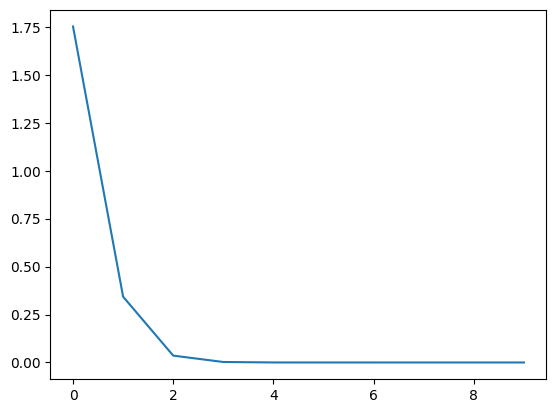

In [40]:
A = operator_A(10)
eig_values, eig_vector = np.linalg.eig(A)
eig_values
plt.plot(eig_values)

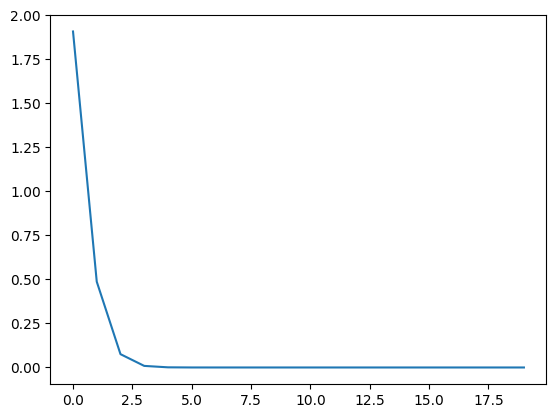

In [41]:
A = operator_A(20)
eig_values, eig_vector = np.linalg.eig(A)
eig_values
plt.plot(eig_values)

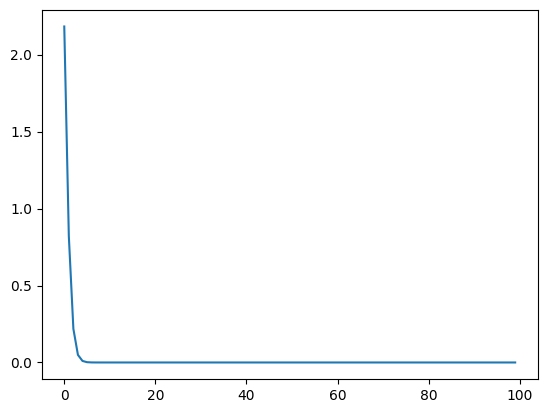

In [42]:
A = operator_A(100)
eig_values, eig_vector = np.linalg.eig(A)
eig_values
plt.plot(eig_values)

Решить систему с зашумленной правой частью

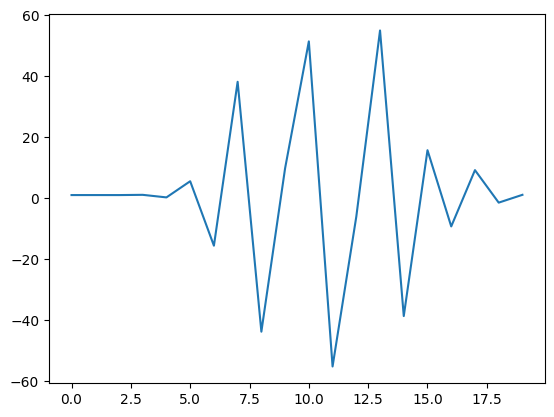

In [43]:
#Ax = b 
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

x = np.linspace(0,1,N)
sigma = np.random.normal(size=N)

b_delta = b + delta * sigma

y = np.linalg.solve(A, b)
plt.plot(y)

Решить систему с помощью регуляризации Тихонова

[0.72445093 1.21465808 1.27136146 1.24880336 1.20584484 1.15776519
 1.10956651 1.06309368 1.01903256 0.97758892 0.93875466 0.90242426
 0.86844982 0.8366684  0.80691601 0.77903469 0.75287594 0.72830208
 0.70518657 0.68341376]
norm B 0.058688899799525296


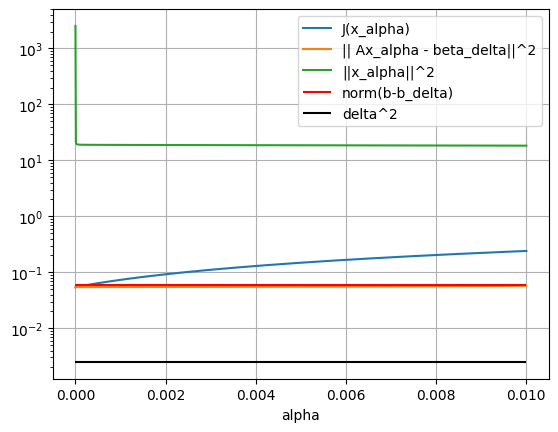

In [44]:
#Ax = b 
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

#x = np.linspace(0,1,N)
sigma = np.random.normal(size=N)

b_delta = b + delta * sigma
def J(A, b_delta, x , alpha):
    return np.linalg.norm(np.matmul(A,x) - b_delta)**2 + alpha * np.linalg.norm(x)**2

E = np.zeros((N,N))
for i in range(N):
    E[i,i] = 1
M = 1000
alphas = np.linspace(1e-7, 1e-2, M)
Jx_alpha = np.zeros(M)
residuals = np.zeros(M)
x_alphas = np.zeros(M)
i = 0
# A.T @ A + alpha @ np.eye(N) 
for alpha in alphas:
    #u = #np.matmul(np.linalg.inv(np.matmul(A.T, A) + alpha * E), np.matmul(A.T, b_delta))
    AT_A = A.T @ A
    AT_b = A.T @ b_delta
    I = np.eye(N)
    u = A.T @ b_delta @ np.linalg.inv(AT_A + alpha * I) #np.linalg.solve(AT_A + alpha * I, AT_b)
    Jx_alpha[i] = J(A, b_delta, u, alpha)
    residuals[i] = np.linalg.norm(np.matmul(A,u) - b_delta)**2
    x_alphas[i] = np.linalg.norm(u)**2
    
    i += 1
plt.plot(alphas, Jx_alpha,  label="J(x_alpha)")
plt.plot(alphas, residuals, label="|| Ax_alpha - beta_delta||^2")
plt.plot(alphas, x_alphas, label="||x_alpha||^2")
plt.xlabel('alpha')
plt.hlines(np.linalg.norm(b - b_delta)**2, alphas[0], alphas[-1], colors='red',label='norm(b-b_delta)')
plt.hlines(delta**2,alphas[0], alphas[-1], colors='black', label='delta^2')
plt.yscale('log')
plt.legend()
plt.grid()
alpha = 0.002
u = np.matmul(np.linalg.inv(np.matmul(A.T, A) + alpha * E), np.matmul(A.T, b_delta))
print(u)
print("norm B", np.linalg.norm(b - b_delta)**2)

[0.72445093 1.21465808 1.27136146 1.24880336 1.20584484 1.15776519
 1.10956651 1.06309368 1.01903256 0.97758892 0.93875466 0.90242426
 0.86844982 0.8366684  0.80691601 0.77903469 0.75287594 0.72830208
 0.70518657 0.68341376]


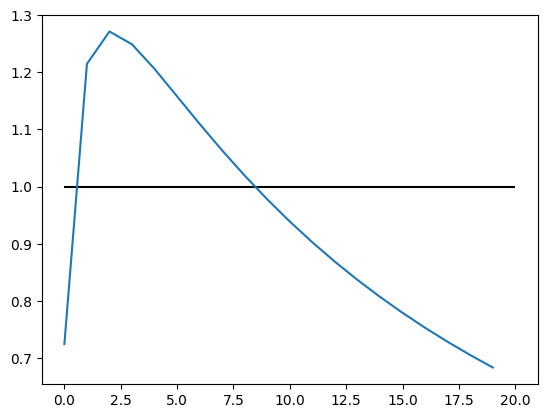

In [45]:
alpha = 0.002
ATA = A.T @ A
ATb = A.T @ b_delta
I = np.eye(N)
u = A.T @ b_delta @ np.linalg.inv(AT_A + alpha * I)

plt.hlines(1, 0, 20, colors='black')
print(u)
plt.plot(u)


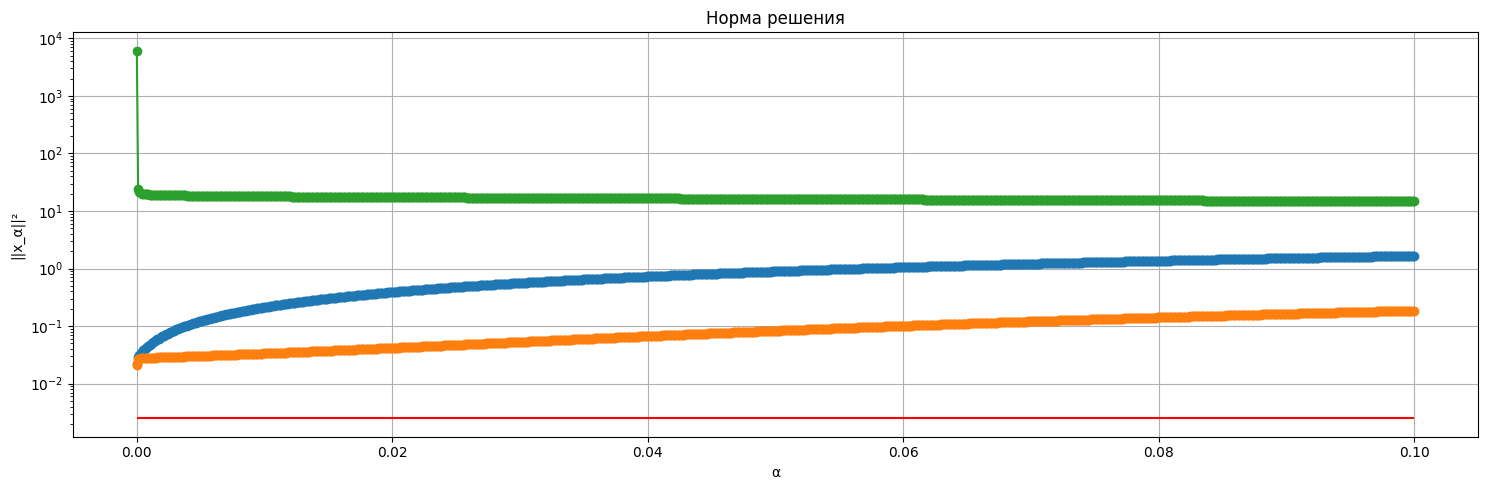

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Входные данные
N = 20
delta = 0.05

A = operator_A(N)
b = np.zeros(N)
for i in range(N):
    sumA = 0
    for j in range(N):
        sumA += A[i][j]
    b[i] = sumA 

#x = np.linspace(0,1,N)
sigma = np.random.normal(size=N)

b_delta = b + delta * sigma
M = 1000
alphas = np.linspace(1e-7, 1e-1, M)
# Списки для хранения результатов
J_values = []
residuals = []
norms = []

# Решение для каждого alpha
for alpha in alphas:
    ATA = A.T @ A
    ATb = A.T @ b_delta
    I = np.eye(N)
    x_alpha = np.linalg.solve(ATA + alpha * I, ATb)
    
    # Вычисления
    residual = A @ x_alpha - b_delta
    residual_norm = np.sum(residual**2)
    x_norm = np.sum(x_alpha**2)
    J = residual_norm + alpha * x_norm
    
    # Сохранение
    J_values.append(J)
    residuals.append(residual_norm)
    norms.append(x_norm)

# Графики
plt.figure(figsize=(15, 5))

plt.plot(alphas, J_values, 'o-')
plt.xlabel('α')
plt.ylabel('J(x_α)')
plt.title('Функционал J(x_α)')
plt.grid(True)


plt.plot(alphas, residuals, 'o-')
plt.xlabel('α')
plt.ylabel('||Ax_α - b_δ||²')
plt.title('Невязка')
plt.grid(True)


plt.plot(alphas, norms, 'o-')
plt.xlabel('α')
plt.ylabel('||x_α||²')
plt.title('Норма решения')
plt.grid(True)
plt.hlines(delta**2, alphas[0], alphas[-1], colors='red')
plt.tight_layout()
plt.yscale('log')
plt.show()

[1.2017649  0.51555782 0.83546631 1.08271525 1.21514146 1.2673016
 1.26937345 1.24150655 1.19645214 1.1421796  1.08365254 1.02394797
 0.96495153 0.90779129 0.85311103 0.80124424 0.75232623 0.70636685
 0.66329809 0.62300528]


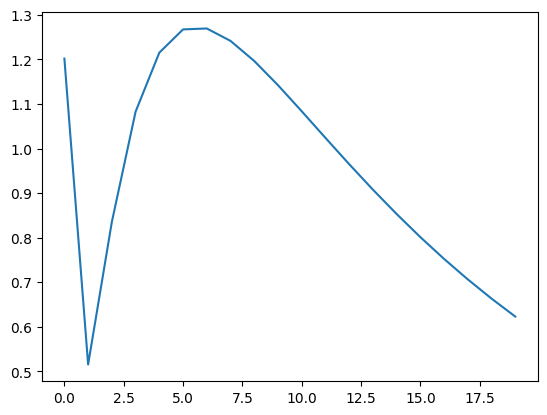

In [47]:
alpha = 0.0005
ATA = A.T @ A
ATb = A.T @ b_delta
I = np.eye(N)
x_alpha = np.linalg.solve(ATA + alpha * I, ATb)
print(x_alpha)
plt.plot(x_alpha)